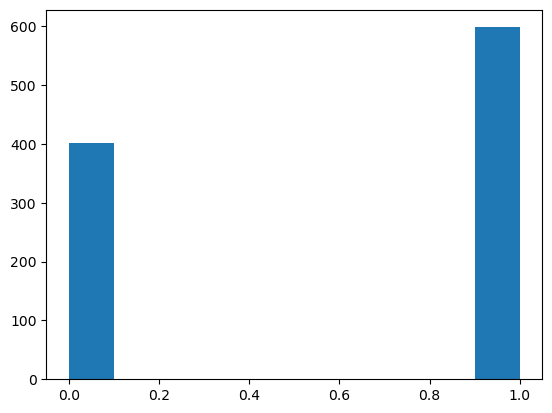

In [98]:
import matplotlib.pyplot as plt
import numpy as np
rng = np.random.default_rng(seed = 42)
def histogram(X, bins = None):
    plt.hist(X, bins = bins)
def ogive(X, bins = None):
    plt.hist(X, cumulative = True, bins = bins)

X = rng.choice([0, 1], size = 1000, p = [0.4, 0.6])
histogram(X)

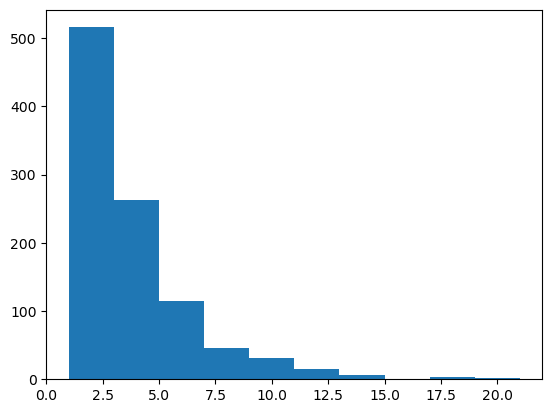

In [99]:
X = rng.geometric(p = 0.31, size = 1000)
histogram(X)

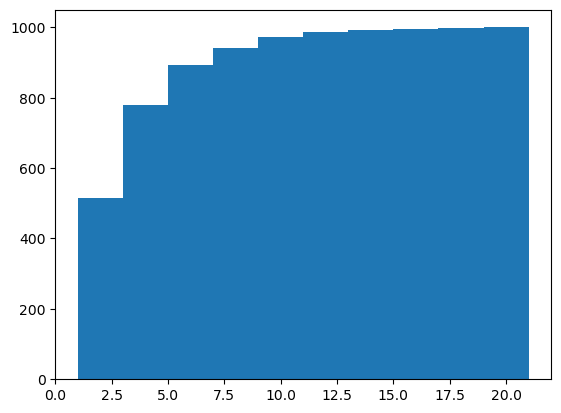

In [100]:
ogive(X)

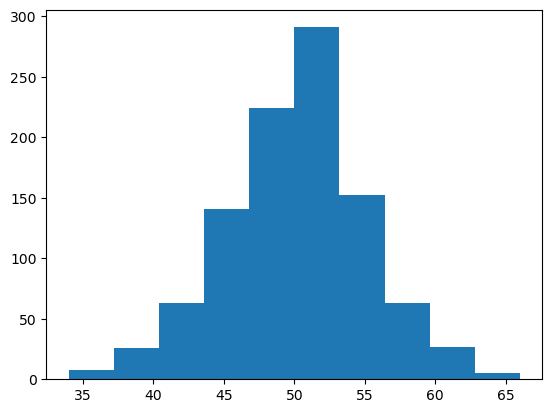

In [101]:
X = rng.binomial(n = 100, p = 0.5, size = 1000)
histogram(X)

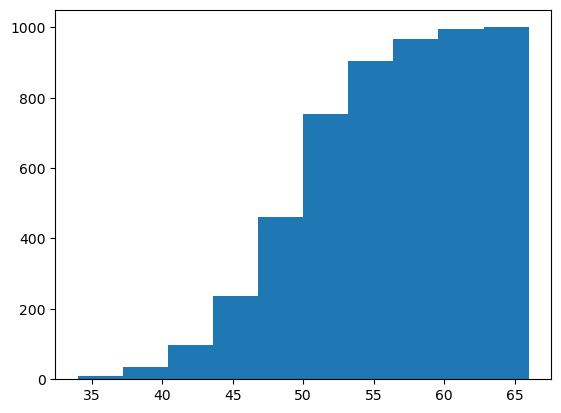

In [102]:
ogive(X)

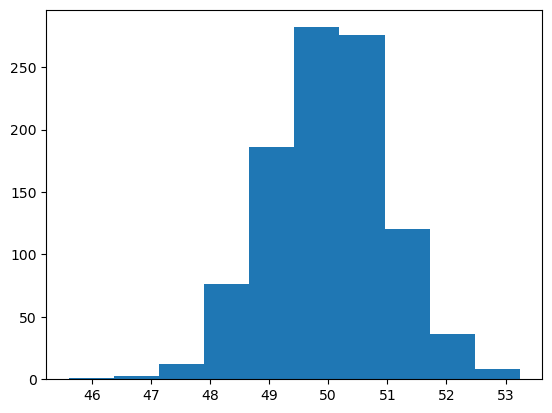

In [103]:
X = rng.normal(size = 1000, loc = 50)
histogram(X)

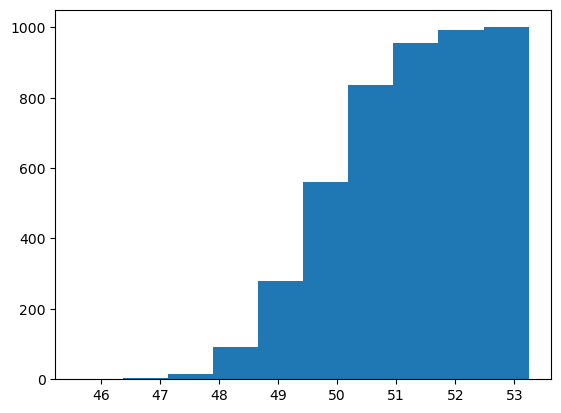

In [104]:
ogive(X)

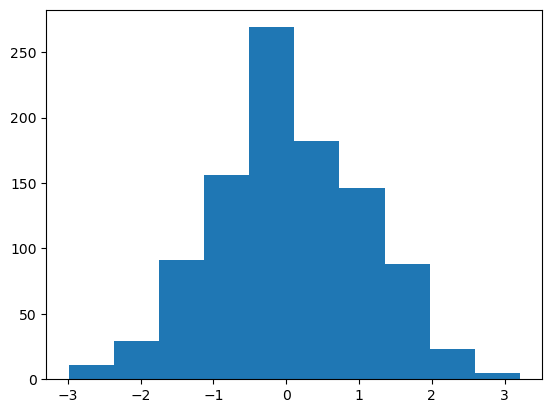

In [105]:
X = rng.standard_normal(size = 1000)
histogram(X)

In [106]:
import pandas as pd

df = pd.read_csv("C:/Users/samue/Documents/code/Statistiska-metoder-Samuel-Airisniemi/P2-python-descriptive-stats/Advertising.csv", index_col = 0)
df.head()

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


# 1 A)

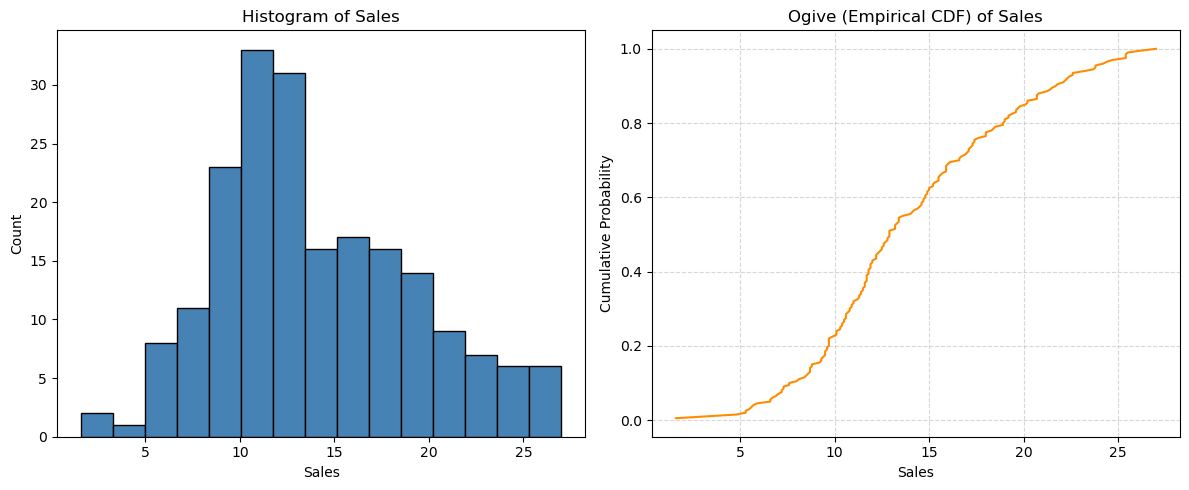

In [107]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv("C:/Users/samue/Documents/code/Statistiska-metoder-Samuel-Airisniemi/P2-python-descriptive-stats/Advertising.csv", index_col=0)

sales = df["Sales"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(sales, bins=15, color="steelblue", edgecolor="black")
axes[0].set_title("Histogram of Sales")
axes[0].set_xlabel("Sales")
axes[0].set_ylabel("Count")

sorted_vals = np.sort(sales)
cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
axes[1].plot(sorted_vals, cdf, color="darkorange")
axes[1].set_title("Ogive (Empirical CDF) of Sales")
axes[1].set_xlabel("Sales")
axes[1].set_ylabel("Cumulative Probability")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Histogrammet visar en relativt symmetrisk fördelning med en svag högerskevhet. Ogiven är S‑formad och liknar en normalfördelning. Det finns ingen tydlig stokastisk process som genererar Sales, så man får göra ett generiskt antagande. En normalfördelning är en rimlig approximation, även om datan inte är perfekt normal.

# 1 B)

Det finns flera matematiska metoder för att avgöra vilken teoretisk fördelning som bäst matchar datan. Man kan använda goodness‑of‑fit‑tester som Kolmogorov–Smirnov eller Anderson–Darling, eller man kan skatta parametrar för olika kandidatfördelningar och jämföra dem med AIC/BIC baserat på maximum likelihood. Man kan också använda Q‑Q‑plots eller transformationer (t.ex. log‑transform) för att visuellt bedöma vilken modell som passar bäst. I praktiken är detta ofta tidskrävande och kräver att man redan har en uppsättning kandidatfördelningar att testa.

# 1 C)

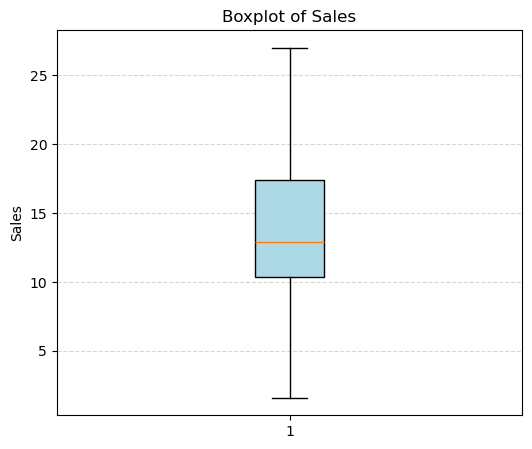

In [108]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("C:/Users/samue/Documents/code/Statistiska-metoder-Samuel-Airisniemi/P2-python-descriptive-stats/Advertising.csv", index_col=0)

plt.figure(figsize=(6, 5))
plt.boxplot(df["Sales"], vert=True, patch_artist=True, boxprops=dict(facecolor="lightblue"))
plt.title("Boxplot of Sales")
plt.ylabel("Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

Jag föredrar histogrammet eftersom det visar fördelningens form och gör det lättare att bedöma om datan är symmetrisk, skev eller tungsvansad. Boxploten är bra för att se median, spridning och outliers, men den döljer detaljer om själva fördelningsformen. För just denna uppgift – att resonera om vilken fördelning Sales liknar – är histogrammet mer informativt.

# 2 A)

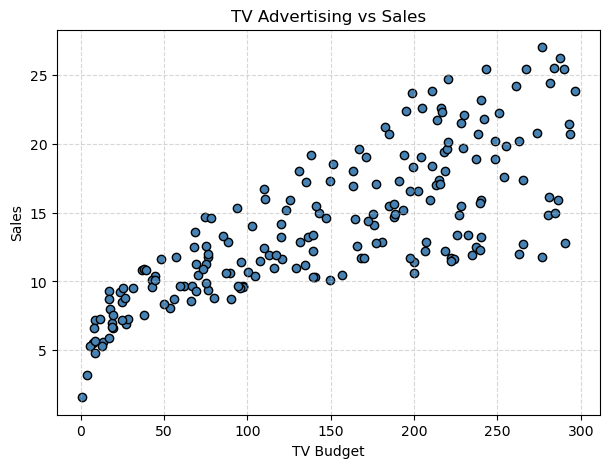

In [109]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("C:/Users/samue/Documents/code/Statistiska-metoder-Samuel-Airisniemi/P2-python-descriptive-stats/Advertising.csv", index_col=0)

plt.figure(figsize=(7, 5))
plt.scatter(df["TV"], df["Sales"], color="steelblue", edgecolor="black")
plt.title("TV Advertising vs Sales")
plt.xlabel("TV Budget")
plt.ylabel("Sales")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# 2 B)

In [110]:
df[["TV", "Sales"]].cov()

,TV,Sales
TV,7370.949893,350.390195
Sales,350.390195,27.221853


In [111]:
df["TV"].corr(df["Sales"])

np.float64(0.7822244248616061)

# 2 C)

Den visuella trenden i scatter‑ploten kan motiveras med matematisk statistik genom att beräkna kovarians och korrelation mellan TV och Sales. Båda är tydligt positiva, vilket indikerar ett linjärt samband. Man kan även testa hypotesen H_0:\rho =0 med ett t‑test för korrelation, där p‑värdet blir mycket litet, vilket innebär att trenden är statistiskt signifikant. Alternativt kan man använda enkel linjär regression och visa att lutningskoefficienten \beta _1 är positiv och signifikant. Alla dessa metoder bekräftar den positiva trend som syns i scatter‑ploten.


# 3)

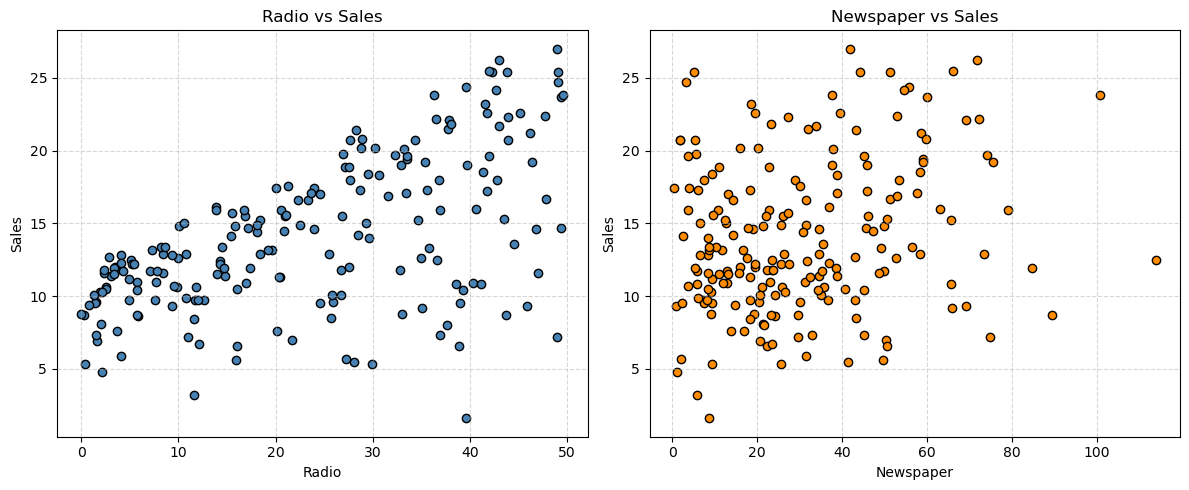

In [112]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("C:/Users/samue/Documents/code/Statistiska-metoder-Samuel-Airisniemi/P2-python-descriptive-stats/Advertising.csv", index_col=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df["Radio"], df["Sales"], color="steelblue", edgecolor="black")
axes[0].set_title("Radio vs Sales")
axes[0].set_xlabel("Radio")
axes[0].set_ylabel("Sales")
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].scatter(df["Newspaper"], df["Sales"], color="darkorange", edgecolor="black")
axes[1].set_title("Newspaper vs Sales")
axes[1].set_xlabel("Newspaper")
axes[1].set_ylabel("Sales")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [113]:
print("Radio-Sales correlation:", df["Radio"].corr(df["Sales"]))
print("Newspaper-Sales correlation:", df["Newspaper"].corr(df["Sales"]))

Radio-Sales correlation: 0.5762225745710551
Newspaper-Sales correlation: 0.22829902637616528


# 4 A)

In [114]:
sales = df["Sales"]

manual_mean = sales.sum() / sales.count()
print("Manual mean:", manual_mean)
print("Pandas mean:", sales.mean())

Manual mean: 14.0225
Pandas mean: 14.0225


# 4 B)

In [115]:
import numpy as np

sales = df["Sales"]

mean = sales.mean()
manual_std = np.sqrt(((sales - mean)**2).sum() / (sales.count() - 1))

print("Manual std:", manual_std)
print("Pandas std:", sales.std())

Manual std: 5.217456565710478
Pandas std: 5.217456565710477


# 4 C)

The command df.describe() computes standard descriptive statistics for each numeric column. The mean is computed as the sum of all values divided by the number of observations, which can be verified manually using sum()/count(). The standard deviation is computed using the sample formula with denominator n-1, which matches numpy’s and pandas’ default. The remaining values represent the minimum, maximum, and quartiles (25%, 50%, 75%), which divide the data into four equal‑sized groups and summarize the distribution’s spread and central tendency.

# 5 A)

In [118]:
df.median()

TV           149.75
Radio         22.90
Newspaper     25.75
Sales         12.90
dtype: float64

In [119]:
df.mode()

,TV,Radio,Newspaper,Sales
0,17.2,4.1,8.7,9.7
1,76.4,5.7,9.3,NaN
2,109.8,NaN,25.6,NaN
3,177.0,NaN,NaN,NaN
4,184.9,NaN,NaN,NaN
5,197.6,NaN,NaN,NaN
6,199.8,NaN,NaN,NaN
7,222.4,NaN,NaN,NaN
8,237.4,NaN,NaN,NaN
9,240.1,NaN,NaN,NaN


# 5 B)

In [117]:
import numpy as np

x = df["Sales"]

mean = x.mean()
manual_var = ((x - mean)**2).sum() / (len(x) - 1)

print("Manual variance:", manual_var)
print("Pandas variance:", x.var())

Manual variance: 27.22185301507538
Pandas variance: 27.221853015075364
